## This question involves the use of multiple linear regression on the Auto data set.

In [1]:
# 匯入所需套件
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.regressionplots import influence_plot, plot_leverage_resid2
import numpy as np

In [2]:
# 讀取 Auto 資料集
url = 'https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Auto.csv'
df = pd.read_csv(url, na_values='?').dropna()

# 將 horsepower 轉為數值（若不是的話）
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(inplace=True)


### (a)

Produce a scatterplot matrix which includes all of the variables in the data set.

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_in

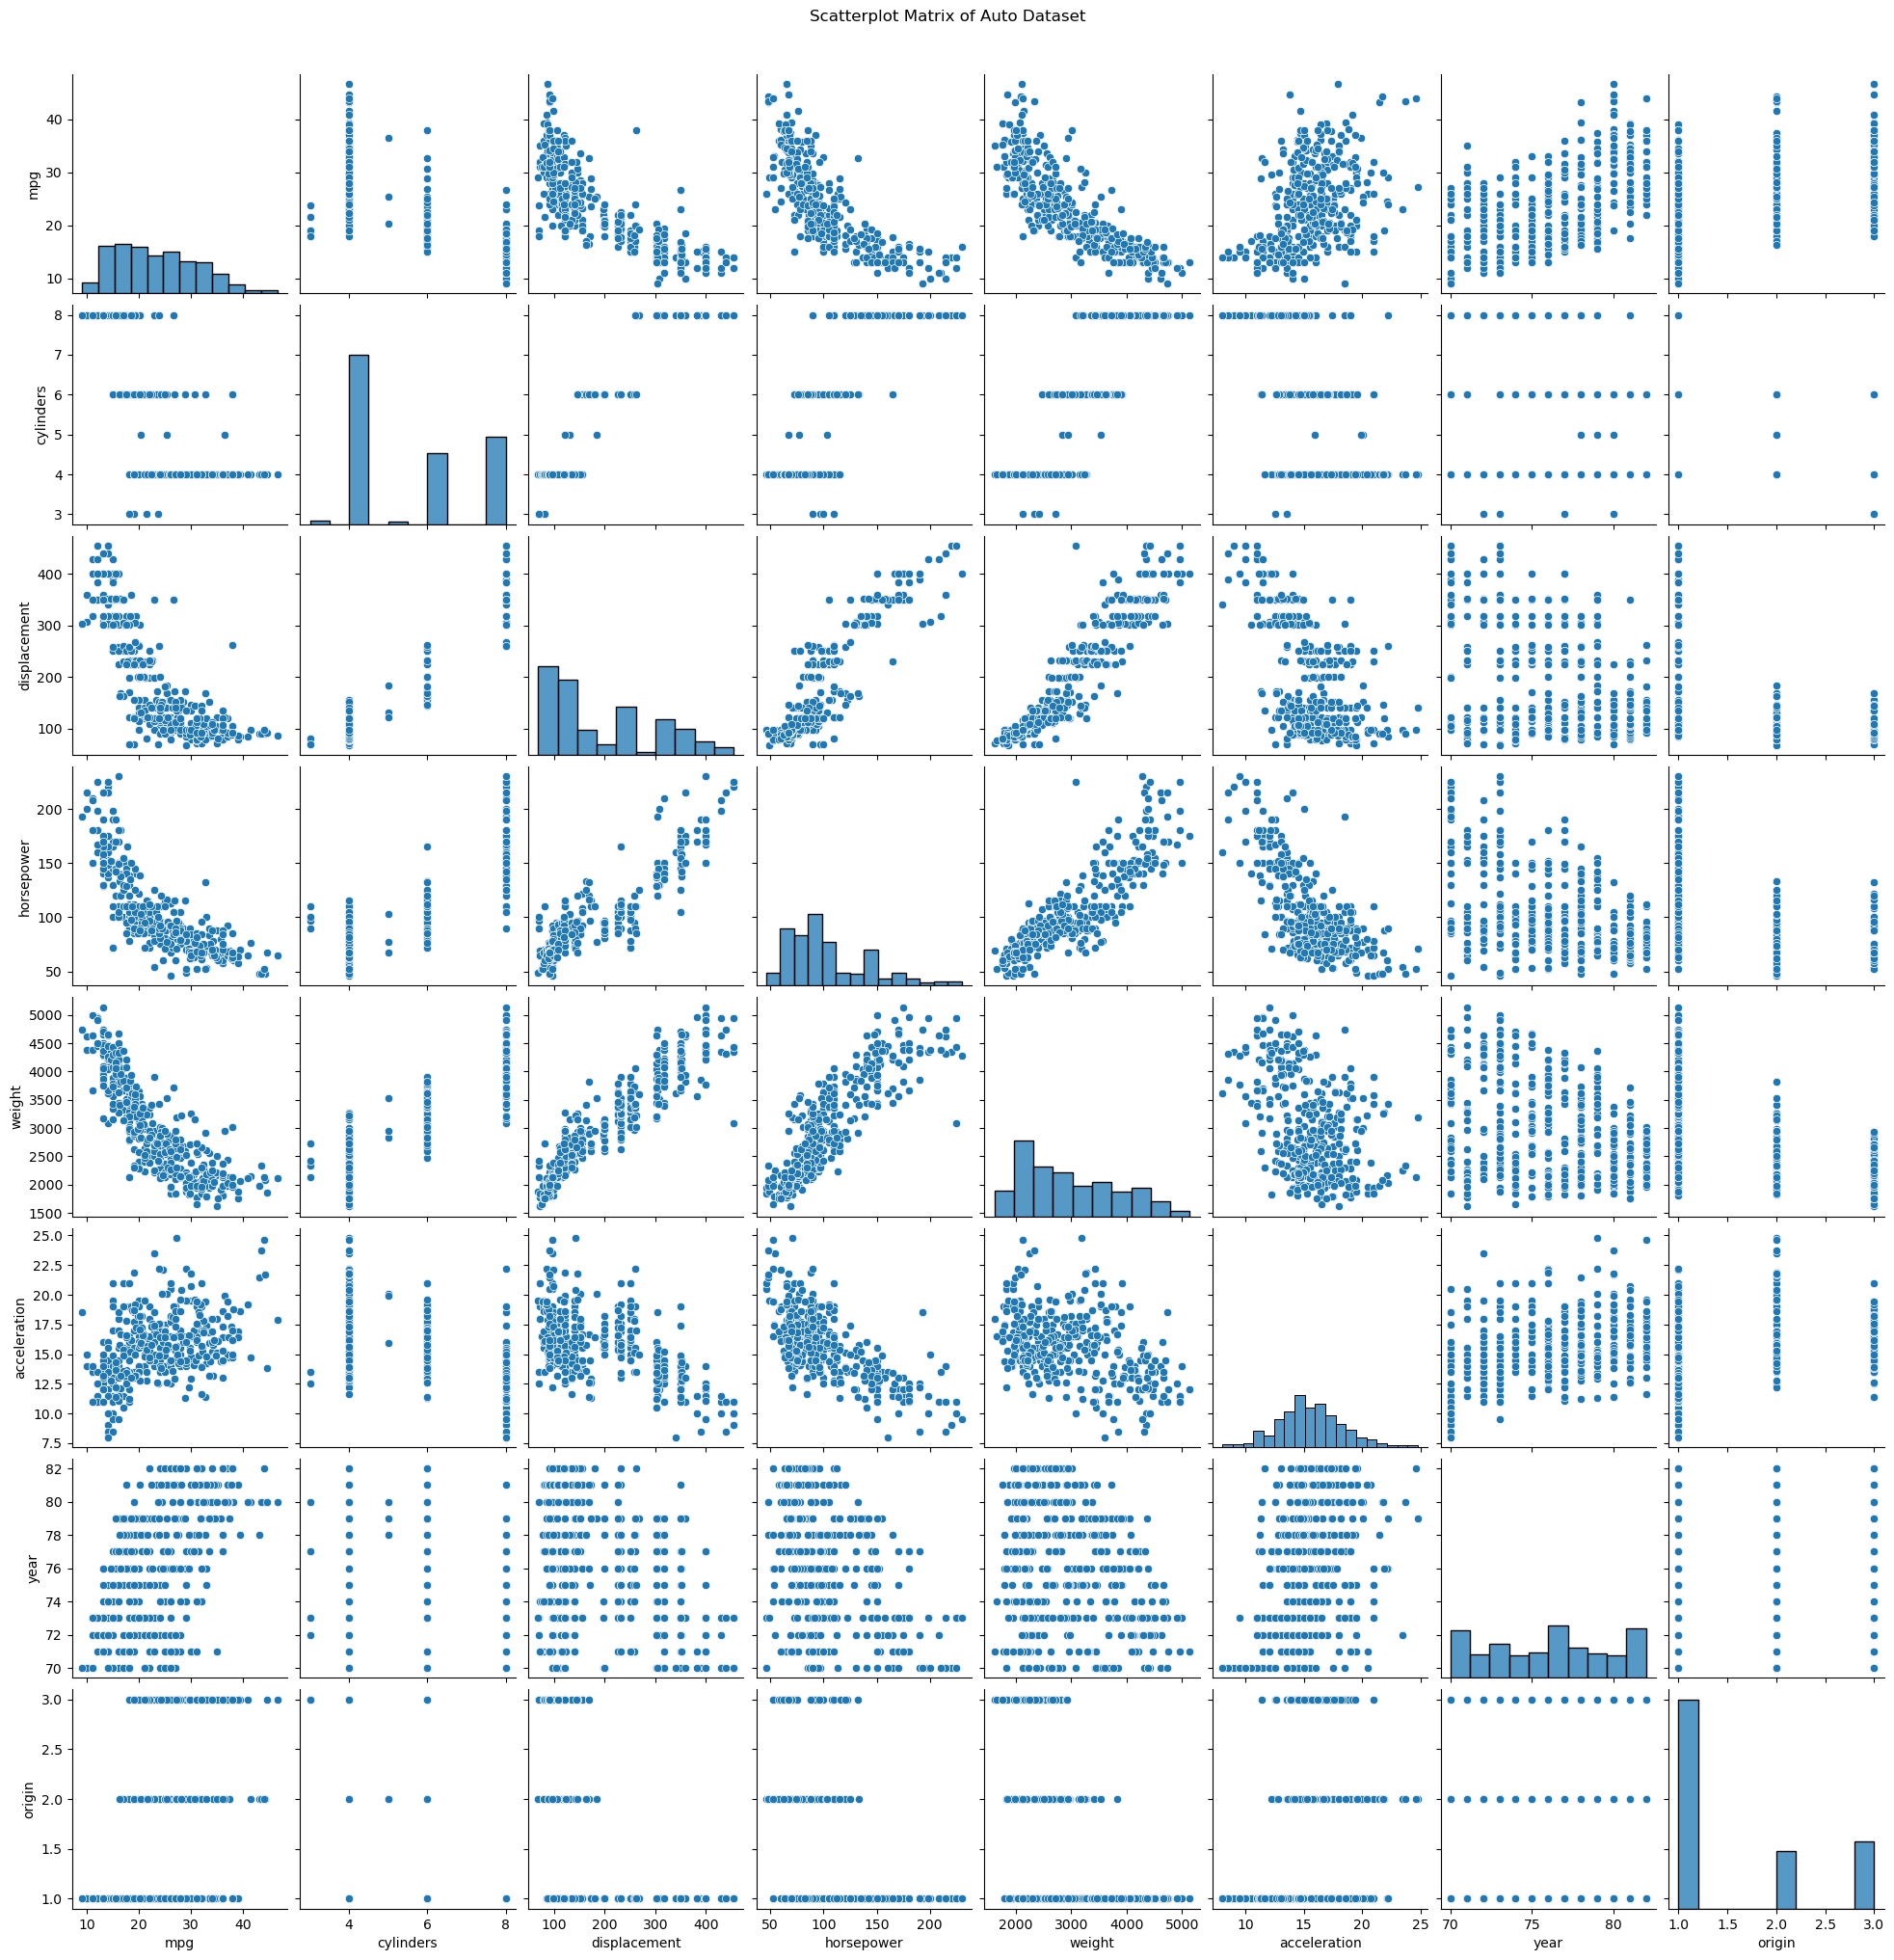

In [3]:
#繪製散佈矩陣（不包含 name 文字欄位）
sns.pairplot(df.drop('name', axis=1))
plt.suptitle("Scatterplot Matrix of Auto Dataset", y=1.02)
plt.show()

### (b)

Compute the matrix of correlations between the variables using the DataFrame.corr() method.


In [4]:
#計算變數之間的相關係數矩陣
corr_matrix = df.drop('name', axis=1).corr()
print("\n(b) 相關係數矩陣：")
print(corr_matrix)



(b) 相關係數矩陣：
                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  0.29031

### (c)

Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. 

In [7]:
#使用 statsmodels 做多元線性回歸：mpg 為應變數，其他為自變數（不含 name）
import statsmodels.formula.api as smf

# 使用公式方式建立模型
model = smf.ols('mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin', data=df).fit()


print("\n(c) 多元回歸摘要：")
print(model.summary())


(c) 多元回歸摘要：
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        15:54:09   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644 

For instance:
i. Is there a relationship between the predictors and the re- sponse? Use the anova_lm() function from statsmodels to answer this question.

In [8]:
# 使用 ANOVA 來檢查是否存在總體關係
print("\n(c-i) ANOVA 結果：")
anova_results = anova_lm(model)
print(anova_results)


(c-i) ANOVA 結果：
                 df        sum_sq       mean_sq            F         PR(>F)
cylinders       1.0  14403.083079  14403.083079  1300.683788  2.319511e-125
displacement    1.0   1073.344025   1073.344025    96.929329   1.530906e-20
horsepower      1.0    403.408069    403.408069    36.430140   3.731128e-09
weight          1.0    975.724953    975.724953    88.113748   5.544461e-19
acceleration    1.0      0.966071      0.966071     0.087242   7.678728e-01
year            1.0   2419.120249   2419.120249   218.460900   1.875281e-39
origin          1.0    291.134494    291.134494    26.291171   4.665681e-07
Residual      384.0   4252.212530     11.073470          NaN            NaN


ii. Which predictors appear to have a statistically significant relationship to the response?

Column PR(>F) are all above p-value 0.05, which indicates that all the variables are significant to mpg

iii. What does the coefficient for the year variable suggest?


In [10]:
year_coef = model.params['year']
print(f" The coefficient of the \n(c-iii) year variable is：{year_coef:.4f}")
print("This means that for every additional year of vehicle age, the average mpg increases by approximately %.2f units." % year_coef)

 The coefficient of the 
(c-iii) year variable is：0.7508
This means that for every additional year of vehicle age, the average mpg increases by approximately 0.75 units.


### (d)

Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


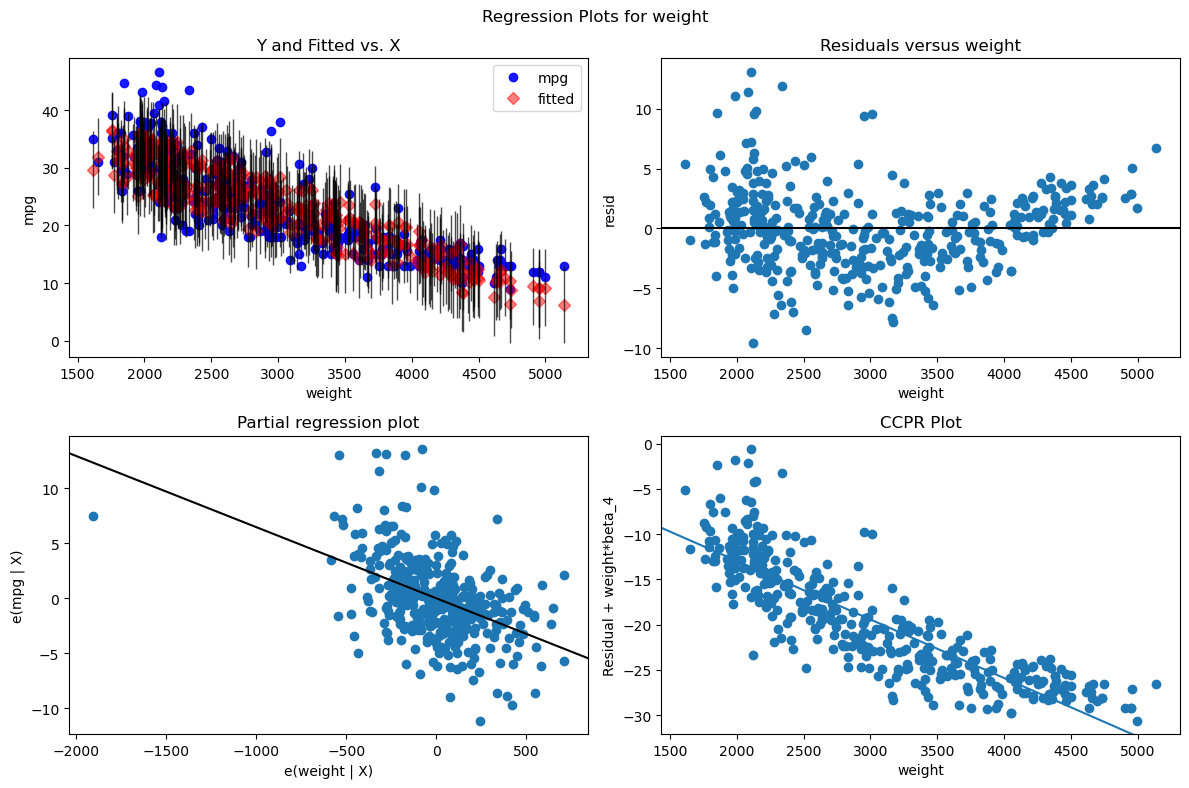

In [11]:
#繪製診斷圖
fig = plt.figure(figsize=(12, 8))
fig = sm.graphics.plot_regress_exog(model, "weight", fig=fig)
plt.tight_layout()
plt.show()


* The residuals vs. weight plot shows a pattern. There is a tendency for the residuals to expand in the left and right tails (especially below 2000 and above 4000).

* A few points have large residuals, indicating potential outliers.

* The partial regression and CCPR plots confirm a strong negative relationship between weight and mpg.

### (e)

Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [13]:
#加入交互作用項（例如：horsepower × weight）
model_inter = smf.ols('mpg ~ cylinders + displacement + horsepower * weight + acceleration + year + origin', data=df).fit()
print("\n(e) 加入交互作用項 horsepower × weight：")
print(model_inter.summary())


(e) 加入交互作用項 horsepower × weight：
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     298.6
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.88e-159
Time:                        16:17:44   Log-Likelihood:                -973.24
No. Observations:                 392   AIC:                             1964.
Df Residuals:                     383   BIC:                             2000.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Inte

The interaction between horsepower and weight is statistically significant (p < 0.001), suggesting that the effect of horsepower on mpg depends on the weight of the car.

### (f)

Try a few different transformations of the variables, such as log(X), √X, X2. Comment on your findings.

In [15]:
#嘗試變數轉換（平方、對數、平方根）
df['log_weight'] = np.log(df['weight'])
df['sqrt_weight'] = np.sqrt(df['weight'])
df['weight2'] = df['weight']**2

model_trans = smf.ols('mpg ~ horsepower + log_weight + acceleration + year + origin', data=df).fit()
print("\n(f) 使用 log(weight) 的模型：")
print(model_trans.summary())

model_trans2 = smf.ols('mpg ~ horsepower + sqrt_weight + acceleration + year + origin', data=df).fit()
print("\n(f) 使用 sqrt(weight) 的模型：")
print(model_trans2.summary())

model_trans3 = smf.ols('mpg ~ horsepower + weight2 + acceleration + year + origin', data=df).fit()
print("\n(f) 使用 weight² 的模型：")
print(model_trans3.summary())


(f) 使用 log(weight) 的模型：
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     410.8
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          4.44e-152
Time:                        16:23:22   Log-Likelihood:                -999.80
No. Observations:                 392   AIC:                             2012.
Df Residuals:                     386   BIC:                             2035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      115.7852

* log(weight) gives the best model fit (highest R² = 0.842).

* All transformations of weight are statistically significant, meaning weight strongly affects mpg.

* The quadratic model (weight²) shows signs of multicollinearity (very high condition number: 3.09e+08), which can make estimates unstable.